In [2]:
import polars as pl
import geopandas as gpd
import glob
import os

In [ ]:
# 1. Recupera la lista dei file
path_pattern = "./dati_fabio/Labial-velars- DALV (1).csv"

# CONTROLLO: Se la lista è vuota, stampa un avviso
if not path_pattern:
    print(f"ERRORE: Nessun file trovato in {os.path.abspath(path_pattern)}")
else:
    print(f"File trovati: {len(path_pattern)}")

    # 2. Leggi e unisci (ora 'files' non è vuota)
    df = pl.read_csv(path_pattern)

    # 3. Converti in Pandas e pulisci eventuali righe con WKT vuoto
    pdf = df.to_pandas().dropna(subset=["WKT"])

    # 4. Crea il GeoDataFrame
    gdf = gpd.GeoDataFrame(
        pdf, geometry=gpd.GeoSeries.from_wkt(pdf["WKT"]), crs="EPSG:4326"
    )

    print("GeoDataFrame creato con successo!")

File trovati: 40
GeoDataFrame creato con successo!


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import io

# URL stabile
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
response = requests.get(url)
world = gpd.read_file(io.StringIO(response.text))

# Identifichiamo la colonna dei nomi (cerca 'name' ignorando maiuscole/minuscole)
colonna_nome = [c for c in world.columns if c.lower() == "name"][0]

# Lista dei paesi desiderati
melanesia_names = ["Papua New Guinea", "Solomon Islands", "Vanuatu", "Fiji"]

# Filtriamo usando la colonna identificata
melanesia_base = world[world[colonna_nome].isin(melanesia_names)]

# Se ancora vuoto (magari per le Solomon Islands), facciamo un controllo parziale
if melanesia_base.empty:
    mask = world[colonna_nome].str.contains(
        "Papua|Solomon|Vanuatu|Fiji", case=False, na=False
    )
    melanesia_base = world[mask]

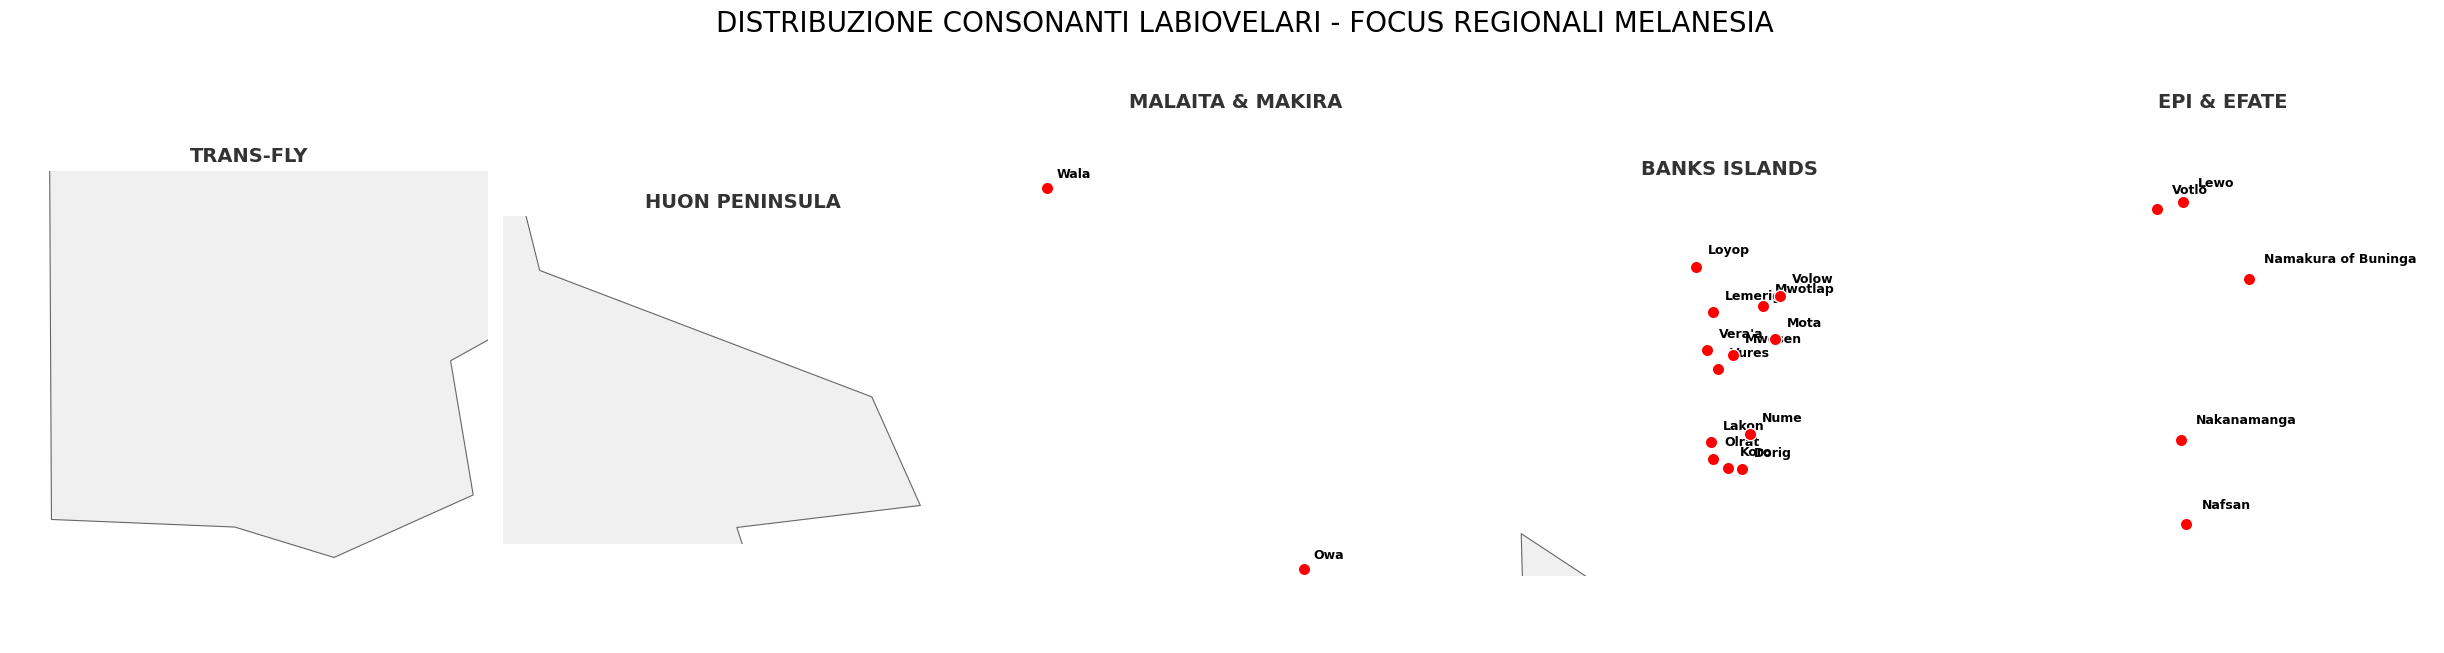

In [ ]:
# Pulizia dati utente (rimozione righe senza geometria, come la n.4 del tuo screen)
gdf_clean = gdf.dropna(subset=["geometry"])

# Definizione dei focus [Long_min, Long_max, Lat_min, Lat_max]
regions = {
    "Trans-fly": [140.8, 143.5, -9.5, -7.2],
    "Huon Peninsula": [145.8, 148.2, -6.8, -5.2],
    "Malaita & Makira": [160.5, 163.0, -11.2, -8.5],
    "Banks Islands": [166.5, 168.5, -14.8, -13.2],  # Qui cadono i tuoi dati!
    "Epi & Efate": [167.8, 169.2, -18.2, -16.5],
}

fig, axes = plt.subplots(1, 5, figsize=(25, 6), facecolor="white")

for i, (name, coords) in enumerate(regions.items()):
    ax = axes[i]

    # 1. Disegna i confini dei paesi
    melanesia_base.plot(ax=ax, color="#f0f0f0", edgecolor="#666666", linewidth=0.8)

    # 2. Disegna i tuoi punti (consonanti)
    # Usiamo zorder=5 per assicurarci che i punti siano SOPRA la mappa
    gdf_clean.plot(
        ax=ax, color="red", markersize=80, edgecolors="white", linewidth=1, zorder=5
    )

    # 3. Aggiungi etichette per i punti (opzionale)
    for x, y, label in zip(
        gdf_clean.geometry.x, gdf_clean.geometry.y, gdf_clean["name"]
    ):
        if coords[0] <= x <= coords[1] and coords[2] <= y <= coords[3]:
            ax.text(x + 0.05, y + 0.05, str(label), fontsize=9, fontweight="bold")

    # Zoom e pulizia estetica
    ax.set_xlim(coords[0], coords[1])
    ax.set_ylim(coords[2], coords[3])
    ax.set_title(name.upper(), fontsize=14, fontweight="black", color="#333333")
    ax.set_axis_off()

plt.suptitle(
    "DISTRIBUZIONE CONSONANTI LABIOVELARI - FOCUS REGIONALI MELANESIA",
    fontsize=20,
    y=1.08,
)
plt.tight_layout()
plt.show()

C:\Users\SILVIA\AppData\Local\Temp\ipykernel_6956\3653195089.py:76: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower right', frameon=True, facecolor='white')


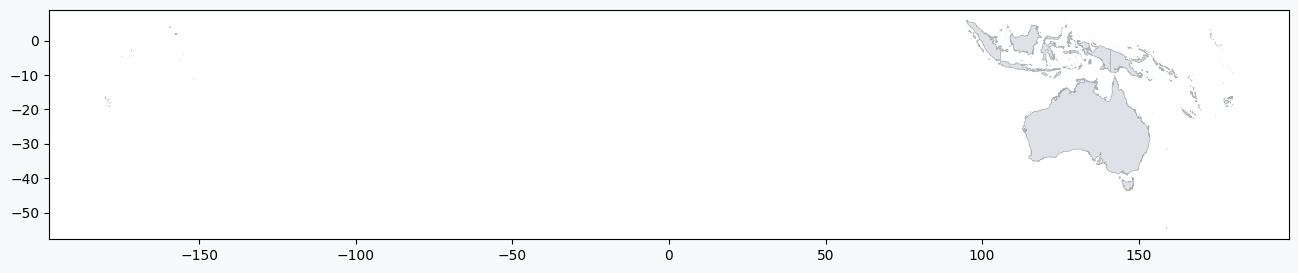

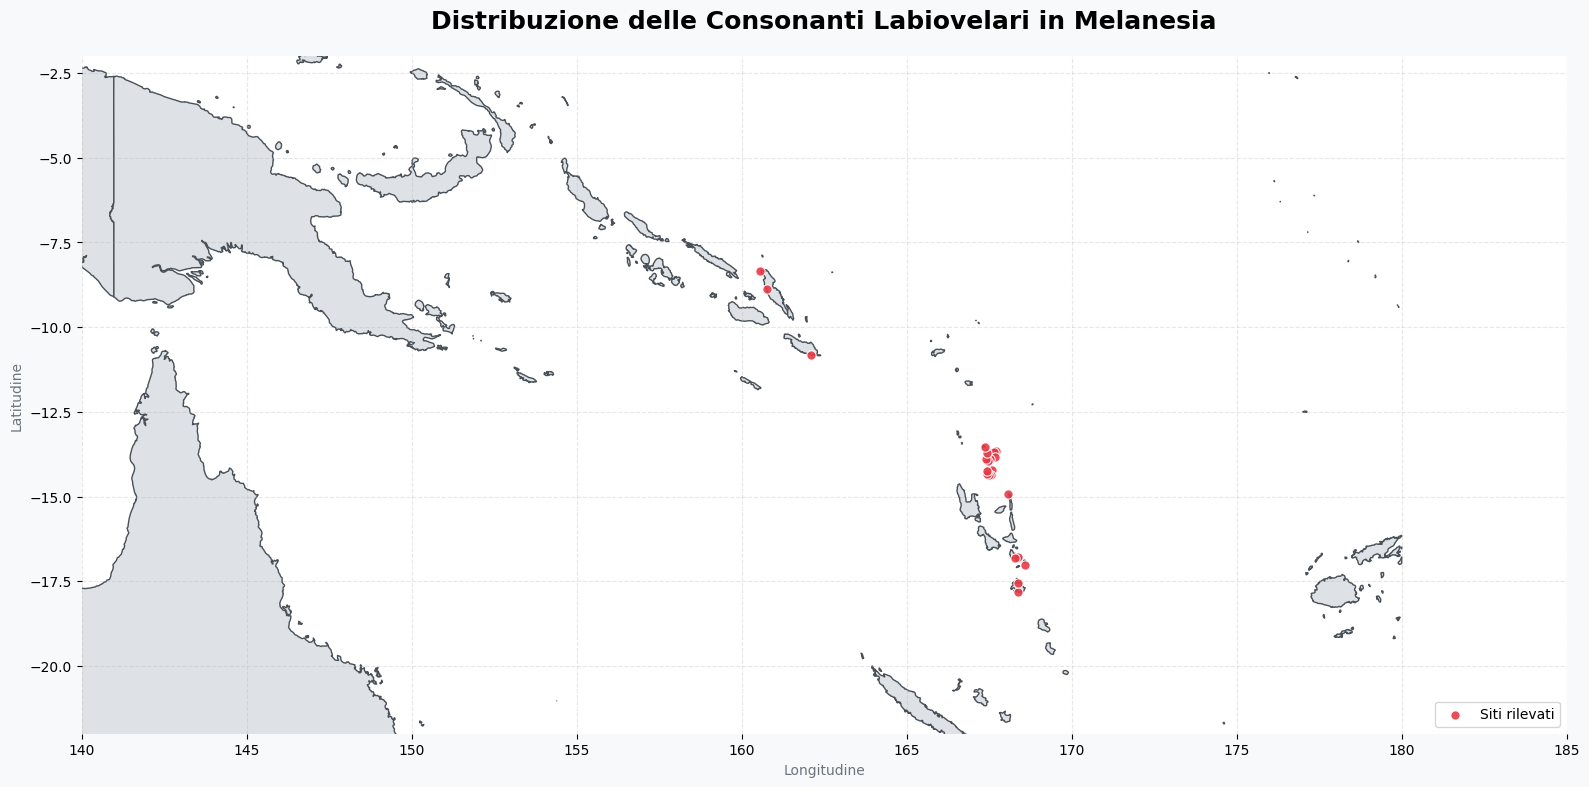

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import io

# 1. Caricamento della mappa di base (stesso metodo "blindato" di prima)
# Use the 10m (high resolution) dataset instead of 110m
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries.geojson"
response = requests.get(url)
world = gpd.read_file(io.StringIO(response.text))


# ... (loading 'world' using the 10m URL as you already are) ...

# Define the bounding box for Melanesia
# [min_lon, min_lat, max_lon, max_lat]
bbox = [140, -22, 185, -2]

# Filter the base map spatially rather than by name
# This captures EVERYTHING (islands, reefs, etc.) in that area
melanesia_base = world.cx[bbox[0] : bbox[2], bbox[1] : bbox[3]]

# 3. Creazione della Mappa Unica
fig, ax = plt.subplots(figsize=(16, 8), facecolor="#f8f9fa")

# We draw the background map
# Using 'edgecolor' helps define very small islands that have no fill area
melanesia_base.plot(ax=ax, color="#dee2e6", edgecolor="#a9afb5", linewidth=0.5)

# ... (rest of your plotting code for gdf_clean) ...


# Identifichiamo la colonna dei nomi e filtriamo per la Melanesia
# colonna_nome = [c for c in world.columns if c.lower() == 'name'][0]
# melanesia_names = ["Papua New Guinea", "Solomon Islands", "Vanuatu", "Fiji", "New Caledonia"]
# melanesia_base = world[world[colonna_nome].isin(melanesia_names)]

# 2. Pulizia dei tuoi dati
gdf_clean = gdf.dropna(subset=["geometry"])

# 3. Creazione della Mappa Unica
fig, ax = plt.subplots(figsize=(16, 8), facecolor="#f8f9fa")

# Disegniamo i confini dei paesi melanesiani
melanesia_base.plot(
    ax=ax, color="#dee2e6", edgecolor="#495057", linewidth=1, label="Terraferma"
)

# Disegniamo tutti i punti delle consonanti labiovelari
gdf_clean.plot(
    ax=ax,
    color="#e63946",  # Rosso vivido
    markersize=45,  # Dimensione media per visibilità d'insieme
    edgecolors="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=5,
    label="Siti rilevati",
)

# Impostiamo lo zoom sull'intera regione Melanesia
# Longitudine da 140 a 185, Latitudine da -22 a -2
ax.set_xlim(140, 185)
ax.set_ylim(-22, -2)

# Personalizzazione estetica
ax.set_title(
    "Distribuzione delle Consonanti Labiovelari in Melanesia",
    fontsize=18,
    pad=20,
    fontweight="bold",
)
ax.set_xlabel("Longitudine", fontsize=10, color="#6c757d")
ax.set_ylabel("Latitudine", fontsize=10, color="#6c757d")

# Aggiungiamo una griglia leggera per il riferimento geografico
ax.grid(True, linestyle="--", alpha=0.3, zorder=1)

# Legenda
ax.legend(loc="lower right", frameon=True, facecolor="white")

# Rimuoviamo i bordi del grafico per un look più moderno
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()